# MiniLM Benchmark: Hate & Offensive Speech Classification

In [92]:
import os 
import time

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
sns.set_palette("deep")

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline, set_seed
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from thop import profile

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(42)

## Load Dataset

In [67]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds = ds["validation"].rename_column("text_cleaned", "text")
test_ds = ds["test"].rename_column("text_cleaned", "text")

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 23541
})

In [68]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

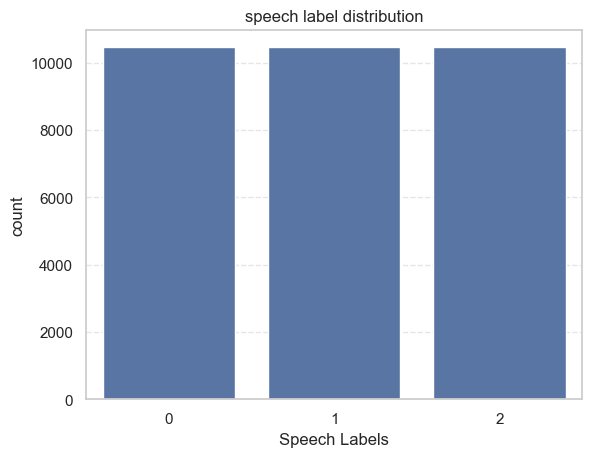

In [69]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.grid(True, axis="y", alpha=0.5, linestyle="--")
plt.show()

In [70]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 3


## Load MiniLM Model

In [71]:
mini_lm = "microsoft/MiniLM-L12-H384-uncased"

mini_lm_tokenizer = AutoTokenizer.from_pretrained(mini_lm)

mini_lm_model = AutoModelForSequenceClassification.from_pretrained(
    mini_lm,
    num_labels=total_labels,
)

mini_lm_model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1527.57it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12,

In [72]:
# Total number of parameters
mini_lm_params = sum(p.numel() for p in mini_lm_model.parameters() if p.requires_grad)
print(f"MiniLM parameters: {mini_lm_params:,}")

MiniLM parameters: 33,361,155


## Tokenizing Dataset

In [73]:
def tokenize(batch):
    return mini_lm_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_val = val_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_test = test_ds.map(tokenize, batched=True, batch_size=1024)

Map: 100%|██████████| 1962/1962 [00:00<00:00, 5489.38 examples/s]


In [74]:
tokenized_train, tokenized_val, tokenized_test

(Dataset({
     features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 23541
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 5886
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 1962
 }))

In [75]:
# remove the raw text column, we dont want a string
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [76]:
tokenized_train

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 23541
})

## Model Training (Fine Tuning)

In [77]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average="macro")
    recall = recall_score(labels, preds, average="macro")
    f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc, 
        "f1": f1, 
        "precision": precision, 
        "recall": recall
    }

In [78]:
LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCH = 3

output_path = "./results/mini_lm"

training_args = TrainingArguments(
    output_dir=output_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [79]:
data_collator = DataCollatorWithPadding(mini_lm_tokenizer)

In [80]:
trainer = Trainer(
    model=mini_lm_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [81]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.588698,0.540772,0.766565,0.758102,0.782908,0.770246
2,0.484810,0.498971,0.779817,0.771014,0.797853,0.783172
3,0.425460,0.485696,0.784913,0.777338,0.797536,0.787563


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.49it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=4416, training_loss=0.512153691139774, metrics={'train_runtime': 412.8443, 'train_samples_per_second': 171.064, 'train_steps_per_second': 10.697, 'total_flos': 2326106672967168.0, 'train_loss': 0.512153691139774, 'epoch': 3.0})

In [82]:
trainer.save_model(output_path)
mini_lm_tokenizer.save_pretrained(output_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 12.52it/s]


('./results/mini_lm\\tokenizer_config.json',
 './results/mini_lm\\tokenizer.json')

## Model Evaluation

### 1. Performance Metrics

In [ ]:
output_path = "./results/mini_lm"

tokenizer = AutoTokenizer.from_pretrained(output_path)
model = AutoModelForSequenceClassification.from_pretrained(output_path)

model.config.id2label = {
    0: "hate", 
    1: "offensive", 
    2: "neither"
}
model.config.label2id = {v:k for k,v in model.config.id2label.items()}

args = TrainingArguments(per_device_eval_batch_size=16)

trainer = Trainer(
    model=model,
    args=args,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

eval_results = trainer.evaluate(eval_dataset=tokenized_test)
eval_results

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1054.53it/s, Materializing param=classifier.weight]                                      


{'eval_loss': 0.47045984864234924,
 'eval_model_preparation_time': 0.002,
 'eval_accuracy': 0.7951070336391437,
 'eval_f1': 0.789375452580118,
 'eval_precision': 0.8099535700097245,
 'eval_recall': 0.7966335351331657,
 'eval_runtime': 3.4566,
 'eval_samples_per_second': 567.602,
 'eval_steps_per_second': 35.584}

In [107]:
pred = trainer.predict(test_dataset=tokenized_test)
pred.predictions, pred.label_ids

(array([[-0.6846225, -1.6250169,  2.58639  ],
        [ 2.4894629, -1.601721 , -1.2496293],
        [ 0.9390553,  2.1356165, -3.429122 ],
        ...,
        [ 1.1708782,  1.9549932, -3.5235975],
        [-0.9806531, -2.1691325,  3.5299144],
        [ 1.059778 ,  2.03185  , -3.4712863]],
       shape=(1962, 3), dtype=float32),
 array([2, 0, 0, ..., 1, 2, 1], shape=(1962,)))

In [108]:
pred_labels = np.argmax(pred.predictions, axis=1)
pred_labels

array([2, 0, 1, ..., 1, 2, 1], shape=(1962,))

In [109]:
prediction_labels = [
    model.config.id2label[label_id]
    for label_id in pred_labels
]

true_labels = [
    model.config.id2label[int(label_id)]
    for label_id in tokenized_test["label"]
]

In [110]:
y_df = pd.DataFrame({
    "predicted": prediction_labels,
    "true": true_labels,
})
y_df.head()

,predicted,true
0,neither,neither
1,hate,hate
2,offensive,hate
3,offensive,hate
4,offensive,offensive


In [111]:
cm_labels = dict(enumerate(model.config.id2label.values()))

list(cm_labels.values())

['hate', 'offensive', 'neither']

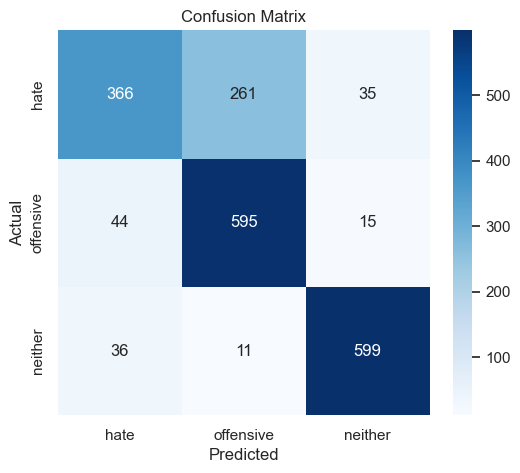

In [112]:
labels = list(cm_labels.values())

cm = confusion_matrix(
    true_labels,
    prediction_labels,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [90]:
report = classification_report(true_labels, prediction_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
hate,0.820628,0.552870,0.660650,662.000000
neither,0.922958,0.927245,0.925097,646.000000
offensive,0.686275,0.909786,0.782380,654.000000
accuracy,0.795107,0.795107,0.795107,0.795107
macro avg,0.809954,0.796634,0.789375,1962.000000
weighted avg,0.809536,0.795107,0.788297,1962.000000


### 2. Compute Metrics

In [101]:
def get_model_size_mb(model):
    param_size = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    buffer_size = 0

    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_mb = (param_size + buffer_size) / 1024**2

    return size_mb

In [102]:
model_size = get_model_size_mb(model)
print(f"Model size: {model_size:.2f} MB")

Model size: 127.27 MB


In [104]:
example_text = "haha i know this is a test sample, but you are so stupid"

inputs = tokenizer(
    example_text,
    return_tensors="pt",
    padding="max_length",
    truncation=True,
    max_length=128
)

inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()

macs, params = profile(
    model,
    inputs=(
        inputs["input_ids"],
        inputs["attention_mask"],
    ),
    verbose=False
)

gflops = macs * 2 / 1e9

print(f"GFLOPs: {gflops:.4f}")

GFLOPs: 5.4459


In [105]:
def measure_latency(model, tokenizer, text, device="cuda", max_length=128, warmup=10, runs=100):
    model.to(device)
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(**inputs)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(runs):
            _ = model(**inputs)

        if device == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

    latency_ms = ((end - start) / runs) * 1000

    return latency_ms

In [106]:
latency = measure_latency(
    model=model,
    tokenizer=tokenizer,
    text=example_text,
    device=device,
    max_length=128
)

print(f"Inference latency: {latency:.2f} ms/sample")

Inference latency: 4.12 ms/sample


# Inference Example

In [113]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

print("input text:", example_text)
classifier(example_text)

input text: haha i know this is a test sample, but you are so stupid


[{'label': 'hate', 'score': 0.8208412528038025}]